In [ ]:
!pip install git+https://github.com/pycaret/pycaret.git@master

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-mvgx2c7c
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-mvgx2c7c
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yfin

In [ ]:
#Task A Question A
ticker = 'AMZN'
ticker = yfin.Ticker(ticker)

data = ticker.history(period='5y')

In [ ]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-11-30 00:00:00-05:00,160.423996,161.419495,156.277496,158.401993,81278000,0.0,0.0
2020-12-01 00:00:00-05:00,159.425003,162.447495,157.858994,161.003998,90740000,0.0,0.0
2020-12-02 00:00:00-05:00,161.082504,161.600006,158.662994,160.176498,62586000,0.0,0.0
2020-12-03 00:00:00-05:00,160.272995,161.432007,159.065506,159.336502,57840000,0.0,0.0
2020-12-04 00:00:00-05:00,159.910507,159.910507,157.938004,158.128998,58272000,0.0,0.0
...,...,...,...,...,...,...,...
2025-11-21 00:00:00-05:00,216.350006,222.210007,215.179993,220.690002,68490500,0.0,0.0
2025-11-24 00:00:00-05:00,222.559998,227.330002,222.270004,226.279999,54318400,0.0,0.0
2025-11-25 00:00:00-05:00,226.380005,230.520004,223.800003,229.669998,39379300,0.0,0.0


<Axes: xlabel='Date', ylabel='Amazon'>

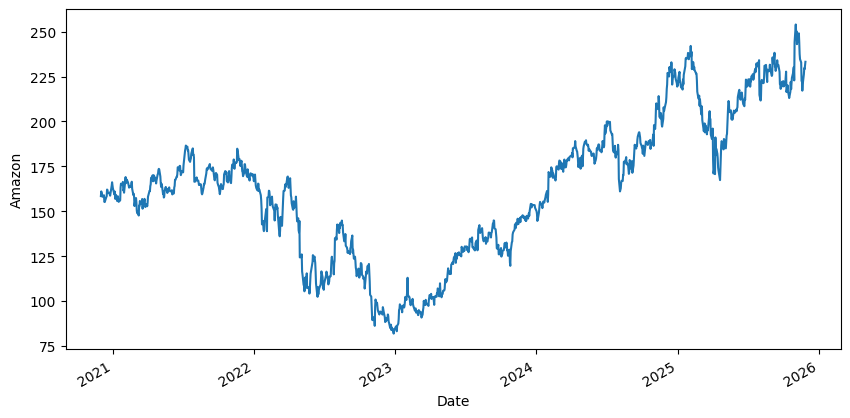

In [ ]:
plt.ylabel("Amazon")

data['Close'].plot(figsize=(10,5))

In [ ]:
#Task A Question B
data['SMA_20'] = data['Close'].rolling(window=20).mean()
data['SMA_50'] = data['Close'].rolling(window=50).mean()

data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

delta = data['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSI
Date,,,,,,,,,,,
2020-11-30 00:00:00-05:00,160.423996,161.419495,156.277496,158.401993,81278000,0.0,0.0,NaN,NaN,158.401993,NaN
2020-12-01 00:00:00-05:00,159.425003,162.447495,157.858994,161.003998,90740000,0.0,0.0,NaN,NaN,158.649803,NaN
2020-12-02 00:00:00-05:00,161.082504,161.600006,158.662994,160.176498,62586000,0.0,0.0,NaN,NaN,158.795202,NaN
2020-12-03 00:00:00-05:00,160.272995,161.432007,159.065506,159.336502,57840000,0.0,0.0,NaN,NaN,158.846755,NaN
2020-12-04 00:00:00-05:00,159.910507,159.910507,157.938004,158.128998,58272000,0.0,0.0,NaN,NaN,158.778397,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-21 00:00:00-05:00,216.350006,222.210007,215.179993,220.690002,68490500,0.0,0.0,236.224001,227.767400,231.353870,19.479574
2025-11-24 00:00:00-05:00,222.559998,227.330002,222.270004,226.279999,54318400,0.0,0.0,236.189500,227.664400,230.870645,29.235757
2025-11-25 00:00:00-05:00,226.380005,230.520004,223.800003,229.669998,39379300,0.0,0.0,236.210500,227.576800,230.756297,32.298680


In [ ]:
data = data.dropna()



In [ ]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSI
Date,,,,,,,,,,,
2021-02-10 00:00:00-05:00,165.699997,165.897507,162.699997,164.328995,63032000,0.0,0.0,163.276449,160.952540,163.879217,48.056659
2021-02-11 00:00:00-05:00,164.600006,164.600006,162.403000,163.106506,46028000,0.0,0.0,163.517049,161.046630,163.805625,47.185990
2021-02-12 00:00:00-05:00,162.500000,164.012497,161.665497,163.885498,46706000,0.0,0.0,163.892649,161.104260,163.813232,48.515395
2021-02-16 00:00:00-05:00,162.702499,165.414993,162.679504,163.447495,51494000,0.0,0.0,164.304399,161.169680,163.778400,44.556965
2021-02-17 00:00:00-05:00,163.179993,166.045502,162.975006,165.432007,65950000,0.0,0.0,164.774100,161.291590,163.935887,58.067475
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-21 00:00:00-05:00,216.350006,222.210007,215.179993,220.690002,68490500,0.0,0.0,236.224001,227.767400,231.353870,19.479574
2025-11-24 00:00:00-05:00,222.559998,227.330002,222.270004,226.279999,54318400,0.0,0.0,236.189500,227.664400,230.870645,29.235757
2025-11-25 00:00:00-05:00,226.380005,230.520004,223.800003,229.669998,39379300,0.0,0.0,236.210500,227.576800,230.756297,32.298680


In [ ]:
# Initialising X and assigning the two feature variables
X = data[['EMA_20','SMA_50']]

# Getting the head of the data
X.head()

,EMA_20,SMA_50
Date,,
2021-02-10 00:00:00-05:00,163.879217,160.95254
2021-02-11 00:00:00-05:00,163.805625,161.04663
2021-02-12 00:00:00-05:00,163.813232,161.10426
2021-02-16 00:00:00-05:00,163.778400,161.16968
2021-02-17 00:00:00-05:00,163.935887,161.29159


In [ ]:
# Setting-up the dependent variable
y = data['Close']

# Getting the head of the data
y.head()

,Close
Date,
2021-02-10 00:00:00-05:00,164.328995
2021-02-11 00:00:00-05:00,163.106506
2021-02-12 00:00:00-05:00,163.885498
2021-02-16 00:00:00-05:00,163.447495
2021-02-17 00:00:00-05:00,165.432007


In [ ]:
#Task A Question C

# Setting the training set to 80% of the data
training = 0.7
t = int(training*len(data))

# Training dataset
X_train = X[:t]
y_train = y[:t]

# Testing dataset
X_test = X[t:]
y_test = y[t:]

In [ ]:
from pycaret.regression import *
s = setup(
    data=data[['EMA_20','SMA_50','Close']],
    target='Close',
    session_id=123,
    numeric_features=['EMA_20', 'SMA_50'],
    fold_strategy='timeseries', # Ensures temporal integrity
    data_split_shuffle=False,     # Prevents random shuffling
    n_jobs=-1
)


,Description,Value
0,Session id,123
1,Target,Close
2,Target type,Regression
3,Original data shape,"(1207, 3)"
4,Transformed data shape,"(1207, 3)"
5,Transformed train set shape,"(844, 3)"
6,Transformed test set shape,"(363, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


In [ ]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [ ]:
rf = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,8.3397,107.3079,10.3590,-1.3583,0.0598,0.0471
1,5.0665,34.1766,5.8461,-0.1145,0.0342,0.0302
2,11.0357,207.1804,14.3938,-0.7004,0.0974,0.0781
3,11.1453,163.5033,12.7868,-0.0254,0.1042,0.0933
4,9.7603,159.2204,12.6183,0.2632,0.1214,0.0997
5,6.1473,50.1856,7.0842,-0.2869,0.0737,0.0636
6,6.2944,69.6234,8.3441,0.4574,0.0764,0.0542
7,14.2853,250.9456,15.8413,-6.8761,0.1238,0.1056
8,4.1503,27.2508,5.2202,0.7453,0.0349,0.0270


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_rf = tune_model(rf)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,8.5808,110.6137,10.5173,-1.4310,0.0608,0.0485
1,4.6845,32.4903,5.7000,-0.0595,0.0335,0.0281
2,11.1611,201.4698,14.1940,-0.6536,0.0961,0.0788
3,13.1993,207.1491,14.3927,-0.2991,0.1187,0.1139
4,10.1607,170.5773,13.0605,0.2107,0.1250,0.1033
5,6.1972,51.1552,7.1523,-0.3118,0.0744,0.0640
6,8.6729,116.4607,10.7917,0.0924,0.0994,0.0754
7,11.2201,162.5273,12.7486,-4.1010,0.0978,0.0825
8,11.9120,160.5153,12.6695,-0.5004,0.0865,0.0775


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
print(tuned_rf)

RandomForestRegressor(n_jobs=-1, random_state=123)


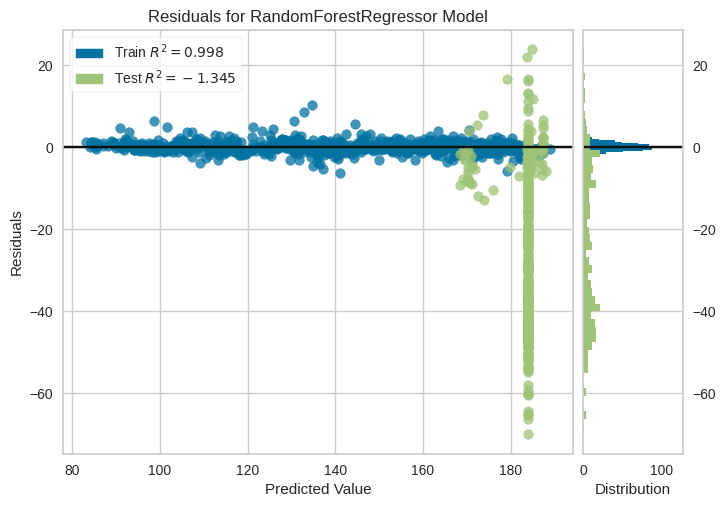

In [ ]:
plot_model(tuned_rf)

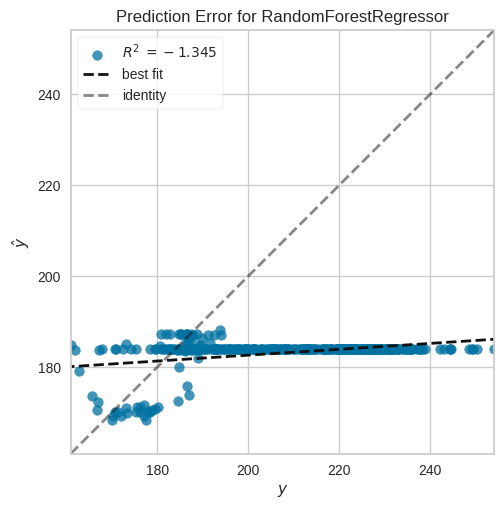

In [ ]:
plot_model(tuned_rf, plot = 'error')

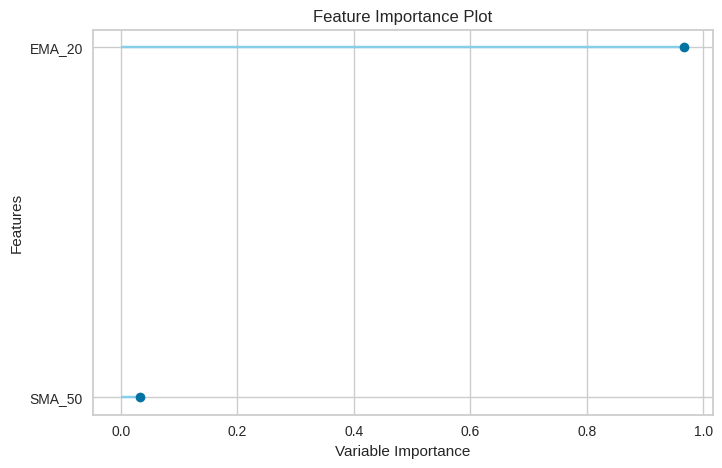

In [ ]:
plot_model(tuned_rf, plot = 'feature')

In [ ]:
evaluate_model(tuned_rf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
predict_model(tuned_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,26.0635,994.6376,31.5379,-1.3449,0.1536,0.1185


,EMA_20,SMA_50,Close,prediction_label
Date,,,,
2024-06-20 00:00:00-04:00,183.712769,182.951797,186.100006,183.636599
2024-06-21 00:00:00-04:00,184.223938,183.014404,189.080002,183.866099
2024-06-24 00:00:00-04:00,184.352127,182.944794,185.570007,183.872699
2024-06-25 00:00:00-04:00,184.541458,182.949005,186.339996,183.872699
2024-06-26 00:00:00-04:00,185.405121,183.148804,193.610001,183.945799
...,...,...,...,...
2025-11-21 00:00:00-05:00,231.353867,227.767395,220.690002,183.945799
2025-11-24 00:00:00-05:00,230.870651,227.664398,226.279999,183.945799
2025-11-25 00:00:00-05:00,230.756302,227.576797,229.669998,183.945799


In [ ]:
final_rf = finalize_model(tuned_rf)

In [ ]:
print(final_rf)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['EMA_20', 'SMA_50'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('actual_estimator',
                 RandomForestRegressor(n_jobs=-1, random_state=123))])


In [ ]:
predict_model(final_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,1.5280,5.0322,2.2433,0.9881,0.0106,0.0074


,EMA_20,SMA_50,Close,prediction_label
Date,,,,
2024-06-20 00:00:00-04:00,183.712769,182.951797,186.100006,185.413604
2024-06-21 00:00:00-04:00,184.223938,183.014404,189.080002,187.769402
2024-06-24 00:00:00-04:00,184.352127,182.944794,185.570007,185.704805
2024-06-25 00:00:00-04:00,184.541458,182.949005,186.339996,185.074599
2024-06-26 00:00:00-04:00,185.405121,183.148804,193.610001,191.462202
...,...,...,...,...
2025-11-21 00:00:00-05:00,231.353867,227.767395,220.690002,222.964301
2025-11-24 00:00:00-05:00,230.870651,227.664398,226.279999,227.707599
2025-11-25 00:00:00-05:00,230.756302,227.576797,229.669998,230.178899


In [ ]:
unseenrf_predictions = predict_model(final_rf, data=data_test)
unseenrf_predictions.head()

,EMA_20,SMA_50,prediction_label
Date,,,
2024-06-20 00:00:00-04:00,183.712769,182.951797,185.413604
2024-06-21 00:00:00-04:00,184.223938,183.014404,187.769402
2024-06-24 00:00:00-04:00,184.352127,182.944794,185.704805
2024-06-25 00:00:00-04:00,184.541458,182.949005,185.074599
2024-06-26 00:00:00-04:00,185.405121,183.148804,191.462202


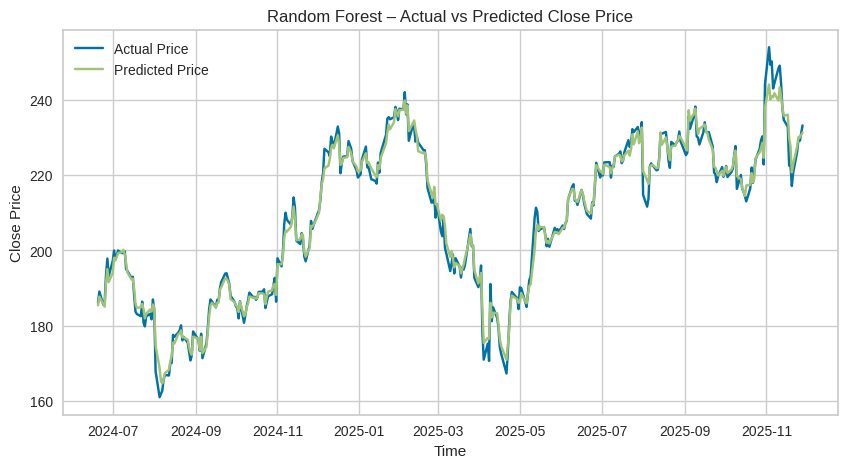

In [ ]:
rf_results = unseenrf_predictions.copy()
rf_results['Actual_Close'] = y_test.values
rf_results.rename(columns={'prediction_label': 'Predicted_Close'}, inplace=True)

plt.figure(figsize=(10, 5))

plt.plot(rf_results.index, rf_results['Actual_Close'], label='Actual Price')
plt.plot(rf_results.index, rf_results['Predicted_Close'], label='Predicted Price')

plt.title("Random Forest – Actual vs Predicted Close Price")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()


